# 05_feature_analysis: 사용자 지정 16개 피처 분석 및 모델 해석

이 노트북은 사용자 정의 **16개 피처**를 활용하여 05c 단계의 학습 로직(단일 LightGBM 모델)을 적용하고 성능 검증 및 글로벌/로컬 SHAP 해석을 수행합니다.

## 분석 흐름
1. **환경 설정 및 한글 폰트 적용**: 시각화 시 한글 깨짐 방지 및 독립 실행 설정
2. **데이터셋 로드**: `data2/04_feature_engineering`에서 원본 로드 후 `date >= '2014-04-01'` 필터링 및 16개 지정 피처 선택
3. **단일 LightGBM 모델 학습**: 05c의 하이퍼파라미터 및 학습 로직 그대로 적용 (GPU 자동 감지 연동)
4. **임계값 튜닝**: 검증 데이터 기준 Disk FAR <= 1.0%를 만족하는 최적 임계값 $T$ 탐색
5. **개체 단위 성능 평가**: 개체(Disk) 기준 혼동 행렬 및 분류 지표 시각화
6. **전역적(Global) SHAP 분석**: Beeswarm 및 Bar Plot 시각화
7. **진단 카테고리별 개체 선정**: 정탐(TP), 미탐(FN), 정상 오탐(Normal FP), 고장개체 오탐(Early Alarm) 각 2개씩 총 8개 개체 선정
8. **국소적(Local) SHAP 분석**: 주요 시점 Waterfall Plot 및 30일 시간 흐름에 따른 리스크 및 피처 기여도 Trajectory 시각화

In [262]:
# 1. 라이브러리 임포트 및 한글 폰트 설정
import os
import sys
import warnings
import json
import joblib
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.metrics import confusion_matrix, classification_report
import shap
from pathlib import Path

warnings.filterwarnings("ignore")

# 프로젝트 루트 등록
sys.path.insert(0, os.path.abspath("../.."))

# GPU 가속 지원 여부 동적 체크
def check_gpu():
    try:
        lgb.train({'device': 'gpu', 'verbose': -1},
                  lgb.Dataset(np.zeros((1, 1)), label=[0]))
        return True
    except:
        return False

# 한글 폰트 설정
def _set_korean_font():
    candidates = ["Malgun Gothic", "NanumGothic", "AppleGothic", "DejaVu Sans"]
    for name in candidates:
        if any(name.lower() in f.name.lower() for f in fm.fontManager.ttflist):
            plt.rcParams["font.family"] = name
            break
    plt.rcParams["axes.unicode_minus"] = False

_set_korean_font()
print("✅ 환경 및 한글 폰트 설정 완료 (GPU 사용 가능 여부:", check_gpu(), ")")

✅ 환경 및 한글 폰트 설정 완료 (GPU 사용 가능 여부: True )


In [ ]:
# 2. 데이터 경로 및 파라미터 정의 (05c와 완벽 동일)
from src.eval_core import prepare_disk_level_data, evaluate_detailed_disk_point, run_disk_level_grid_search

class LocalConfig:
    DATA_ROOT = "../../data2"
    # 사용자 지정 피처 추출을 위해 원본 피처 엔지니어링 파일 지정
    TRAIN_PATH = f"{DATA_ROOT}/04_feature_engineering/fs_train.parquet"
    VALIDATION_PATH = f"{DATA_ROOT}/04_feature_engineering/fs_validation.parquet"
    TARGET_COL = "failure"
    SEED = 42
    
    # 05c 하이퍼파라미터
    LGBM_PARAMS = {
        "objective":              "binary",
        "importance_type":        "gain",
        "max_depth":              7,
        "num_leaves":             60,
        "n_estimators":           300,
        "learning_rate":          0.03,
        "device":                 "gpu" if check_gpu() else "cpu",
        "random_state":           SEED,
        "bagging_seed":           SEED,
        "feature_fraction_seed":  SEED,
        "data_random_seed":       SEED,
        "n_jobs":                 -1,
        "verbose":                -1,
    }

FEATURE_COLS = [
"reallocated_pending_ratio",
"total_seeks_14d_mean",
"s194_14d_max",
"smart_187_raw",
"s187_days_since_first",
"workload_intensity",
"s241_diff",
"smart_183_raw",
"total_seeks_28d_asfd",
"smart_9_raw",
"smart_241_raw",
"s187_28d_sum",
"smart_184_raw",
"smart_198_raw",
'multi_error_count',
'age_weighted_workload',
'smart_242_raw',

# "s187_days_since_first",
# "error_density_14d",
# "smart_187_raw",
# "smart_198_raw",
# "total_seeks_28d_asfd",
# "s187_28d_sum",
# "s5_days_since_first",
# "age_weighted_workload",
# "smart_242_raw",
# "smart_241_raw",
# "smart_9_raw",
# "total_seeks_diff",
# "multi_error_count",
# "s241_diff",
# "s194_28d_std",
# "s190_28d_mean",
# "s242_28d_dai",
# "total_reads_7d_asfd",
# "total_reads_7d_max",
# "s194_14d_max",
# "s194_28d_ewma",
# "s194_14d_std",
# "s190_28d_zscore",
# "s190_28d_ewma",
# "smart_184_raw",
# "s199_days_since_last",
# "s194_28d_dai",
]

print(f"✅ {len(FEATURE_COLS)}개 피처 및 LocalConfig 정의 완료")

✅ 27개 피처 및 LocalConfig 정의 완료


In [264]:
# 3. 데이터 로딩 및 정렬/필터링 수행
print("📂 데이터 로딩 및 정렬 수행 중...")
read_cols = ['serial_number', 'date', 'failure'] + FEATURE_COLS

df_train = pd.read_parquet(LocalConfig.TRAIN_PATH, columns=read_cols)
df_train['date'] = pd.to_datetime(df_train['date'])
df_train = df_train[df_train['date'] >= '2014-04-01'].sort_values(["serial_number", "date"]).reset_index(drop=True)

df_val = pd.read_parquet(LocalConfig.VALIDATION_PATH, columns=read_cols)
df_val['date'] = pd.to_datetime(df_val['date'])
df_val = df_val[df_val['date'] >= '2014-04-01'].sort_values(["serial_number", "date"]).reset_index(drop=True)

print(f"✅ Train 데이터 행 수: {len(df_train):,}")
print(f"✅ Validation 데이터 행 수: {len(df_val):,}")

📂 데이터 로딩 및 정렬 수행 중...
✅ Train 데이터 행 수: 5,141,665
✅ Validation 데이터 행 수: 1,247,377


In [265]:
# 4. 단일 LightGBM 모델 학습 (05c 로직 적용)
print("🏋️ LightGBM 모델 학습 중 (Early Stopping 적용)...")

model = lgb.LGBMClassifier(**LocalConfig.LGBM_PARAMS)
model.fit(
    df_train[FEATURE_COLS],
    df_train[LocalConfig.TARGET_COL],
    eval_set=[(df_val[FEATURE_COLS], df_val[LocalConfig.TARGET_COL])],
    eval_metric="average_precision",
    callbacks=[lgb.early_stopping(stopping_rounds=80, verbose=False)]
)

print("✅ 모델 학습 완료!")

🏋️ LightGBM 모델 학습 중 (Early Stopping 적용)...
✅ 모델 학습 완료!


In [ ]:
# 5. 예측 수행 및 최적 임계값 T 탐색 (Validation 세트 기준)
import time
print("🔮 Validation 예측 수행 중...")
val_prob = model.predict_proba(df_val[FEATURE_COLS])[:, 1]

print("Building disk-level validation data...")
disks_data, n_failed, n_normal = prepare_disk_level_data(
    df_val, val_prob, target_col=LocalConfig.TARGET_COL, serial_col="serial_number", date_col="date"
)
print(f"? Failed disks: {n_failed:,} | Normal disks: {n_normal:,}")

# Disk-level rolling inference PR-AUC. window_size=0 means sequential row-by-row inference;
# temporal context is already baked into engineered rolling features.
disk_pr_grid = run_disk_level_grid_search(
    disks_data, np.linspace(0.0001, 0.9999, 1000), [1], n_failed, n_normal,
    log_dir=None, window_size=0, horizon=30
)
disk_pr_sorted = disk_pr_grid.sort_values(by="recall").copy()
disk_pr_sorted["precision"] = disk_pr_sorted["tps"] / (disk_pr_sorted["tps"] + disk_pr_sorted["fps"] + 1e-8)
disk_pr_sorted["precision"] = disk_pr_sorted["precision"].fillna(1.0)
disk_rolling_prauc = float(np.trapz(disk_pr_sorted["precision"].values, disk_pr_sorted["recall"].values))
print(f"Disk rolling inference PR-AUC: {disk_rolling_prauc:.5f}")



=== 개체(Disk) 기준 성능 평가 지표 요약 ===
Disk PR-AUC : 0.30579
              precision    recall  f1-score   support

      Normal       0.59      0.99      0.74       686
     Failure       0.98      0.34      0.50       702

    accuracy                           0.66      1388
   macro avg       0.78      0.66      0.62      1388
weighted avg       0.79      0.66      0.62      1388



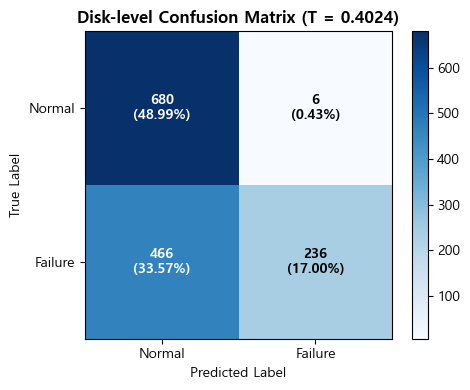

In [267]:
# 6. 개체(Disk) 기준 평가 지표 집계 및 혼동 행렬 시각화
print("\n=== 개체(Disk) 기준 성능 평가 지표 요약 ===")

def compute_disk_prauc(disks_data, n_failed, n_normal):
    from sklearn.metrics import auc
    thresholds = np.linspace(0.0001, 0.9999, 100)
    
    is_failed_arr = np.array([d['is_failed'] for d in disks_data], dtype=bool)
    nth_probs = np.array([np.sort(d['probs'])[::-1][0] if len(d['probs']) >= 1 else 0.0 for d in disks_data])
    
    failed_days = []
    failed_probs = []
    for d in disks_data:
        if d['is_failed']:
            dates = pd.Series(pd.to_datetime(d['dates']))
            failed_days.append((dates.iloc[-1] - dates).dt.days.values)
            failed_probs.append(d['probs'])

    results = []
    for T in thresholds:
        alarmed = (nth_probs >= T)
        fps = np.sum(alarmed & ~is_failed_arr)
        tps = 0
        for dd, dp in zip(failed_days, failed_probs):
            idx_arr = np.where(dp >= T)[0]
            if len(idx_arr) >= 1 and dd[idx_arr[0]] <= 30:
                tps += 1
        results.append({
            'recall': tps / n_failed if n_failed else 0.0,
            'tps': tps,
            'fps': fps
        })
    df_grid = pd.DataFrame(results)
    df_s = df_grid.sort_values("recall").copy()
    df_s["precision"] = df_s["tps"] / (df_s["tps"] + df_s["fps"] + 1e-8)
    df_s["precision"] = df_s["precision"].fillna(1.0)
    return float(auc(df_s["recall"].values, df_s["precision"].values))

disk_prauc = compute_disk_prauc(disks_data, n_failed, n_normal)
print(f"Disk PR-AUC : {disk_prauc:.5f}")

y_true_disk = []
y_pred_disk = []

for d in disks_data:
    probs = d['probs']
    dates = d['dates']
    failures = d['failures']
    is_failed = d['is_failed']
    
    alarm_idx = np.where(probs >= BEST_T)[0]
    has_alarm = len(alarm_idx) > 0
    
    if is_failed:
        y_true_disk.append(1)
        if has_alarm:
            first_alarm_date = pd.Timestamp(dates[alarm_idx[0]])
            fail_date = pd.Timestamp(dates[np.where(failures == 1)[0].max()])
            lead_time = (fail_date - first_alarm_date).days
            if 0 <= lead_time <= 30:
                y_pred_disk.append(1)
            else:
                y_pred_disk.append(0)
        else:
            y_pred_disk.append(0)
    else:
        y_true_disk.append(0)
        y_pred_disk.append(1 if has_alarm else 0)

y_true_disk = np.array(y_true_disk)
y_pred_disk = np.array(y_pred_disk)

print(classification_report(y_true_disk, y_pred_disk, target_names=["Normal", "Failure"]))

cm = confusion_matrix(y_true_disk, y_pred_disk)
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues", interpolation="nearest")
plt.title(f"Disk-level Confusion Matrix (T = {BEST_T:.4f})", fontweight='bold')
plt.colorbar()
plt.xticks([0, 1], ["Normal", "Failure"])
plt.yticks([0, 1], ["Normal", "Failure"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

thresh = cm.max() / 2.
for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{cm[i, j]:,}\n({cm[i, j]/cm.sum()*100:.2f}%)",
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontweight="bold")
plt.tight_layout()
plt.show()

🐝 글로벌 SHAP 중요도 계산 중...


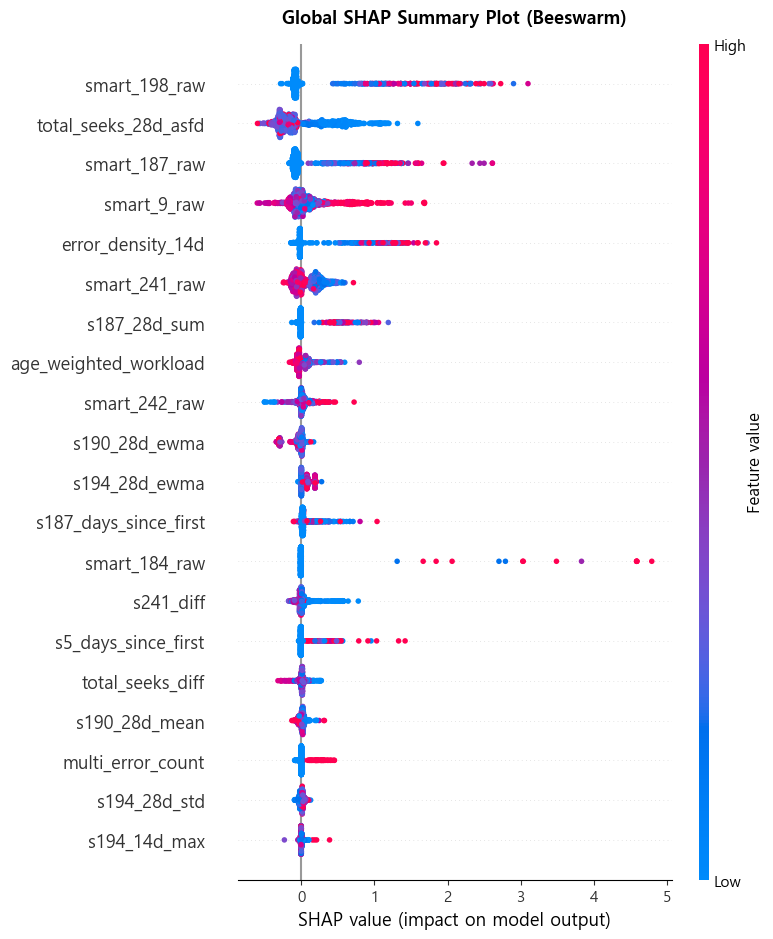

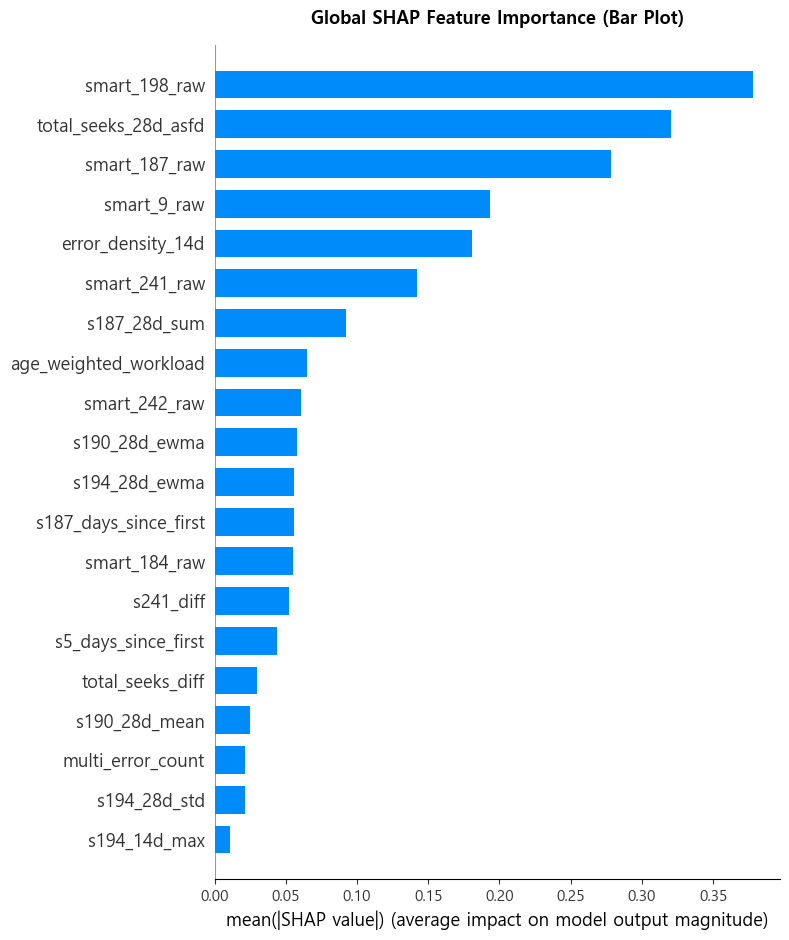

In [268]:
# 7. 글로벌 SHAP 분석
print("🐝 글로벌 SHAP 중요도 계산 중...")
normal_rows = df_val[df_val[LocalConfig.TARGET_COL] == 0]
fail_rows = df_val[df_val[LocalConfig.TARGET_COL] == 1]

shap_sample = pd.concat([
    normal_rows.sample(n=min(500, len(normal_rows)), random_state=LocalConfig.SEED),
    fail_rows.sample(n=min(500, len(fail_rows)), random_state=LocalConfig.SEED)
], ignore_index=True)

X_shap = shap_sample[FEATURE_COLS].copy()
for col in X_shap.columns:
    X_shap[col] = X_shap[col].astype("float32")

explainer = shap.TreeExplainer(model)
sv = explainer.shap_values(X_shap)
if isinstance(sv, list):
    sv = sv[1]

plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_shap, feature_names=FEATURE_COLS, show=False)
plt.title("Global SHAP Summary Plot (Beeswarm)", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_shap, feature_names=FEATURE_COLS, plot_type="bar", show=False)
plt.title("Global SHAP Feature Importance (Bar Plot)", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

In [269]:
# 8. 진단 카테고리별 개체 선정 (TP, FN, Normal FP, Early Alarm 각 2건)
tp_pool = []
fn_pool = []
normal_fp_pool = []
early_fp_pool = []

for d in disks_data:
    probs = d['probs']
    dates = d['dates']
    failures = d['failures']
    is_failed = d['is_failed']
    
    # 알람 발생 인덱스
    alarm_idx = np.where(probs >= BEST_T)[0]
    has_alarm = len(alarm_idx) > 0
    
    if is_failed:
        if has_alarm:
            first_alarm_date = pd.Timestamp(dates[alarm_idx[0]])
            fail_date = pd.Timestamp(dates[np.where(failures == 1)[0].max()])
            lead_time = (fail_date - first_alarm_date).days
            
            if lead_time <= 30:
                tp_pool.append((d['base_serial'], lead_time))
            else:
                early_fp_pool.append((d['base_serial'], lead_time))
        else:
            fn_pool.append(d['base_serial'])
    else:
        if has_alarm:
            normal_fp_pool.append(d['base_serial'])

print(f"🔍 개체 후보 수 -> TP: {len(tp_pool)}, FN: {len(fn_pool)}, Normal FP: {len(normal_fp_pool)}, Early FP: {len(early_fp_pool)}")

import random
random.seed(LocalConfig.SEED)
selected_tp = random.sample(tp_pool, min(2, len(tp_pool)))
selected_fn = random.sample(fn_pool, min(2, len(fn_pool)))
selected_normal_fp = random.sample(normal_fp_pool, min(2, len(normal_fp_pool)))
selected_early_fp = random.sample(early_fp_pool, min(2, len(early_fp_pool)))

cases = {
    "정탐 (True Positive)": [x[0] for x in selected_tp],
    "미탐 (False Negative)": selected_fn,
    "정상에서의 오탐 (Normal False Alarm)": selected_normal_fp,
    "고장개체에서의 오탐 (Early Alarm)": [x[0] for x in selected_early_fp]
}

print("\n🎯 최종 분석 대상 개체 선정:")
for cat, serials in cases.items():
    print(f"  - {cat}: {serials}")

🔍 개체 후보 수 -> TP: 236, FN: 322, Normal FP: 6, Early FP: 144

🎯 최종 분석 대상 개체 선정:
  - 정탐 (True Positive): ['Z304HSDZ', 'S301NJE9']
  - 미탐 (False Negative): ['S300YC4L', 'Z3012X52']
  - 정상에서의 오탐 (Normal False Alarm): ['Z3016SCG', 'Z303XYTM']
  - 고장개체에서의 오탐 (Early Alarm): ['Z300GZ9R', 'W300SQYG']


Waterfall 플롯을 생성합니다...


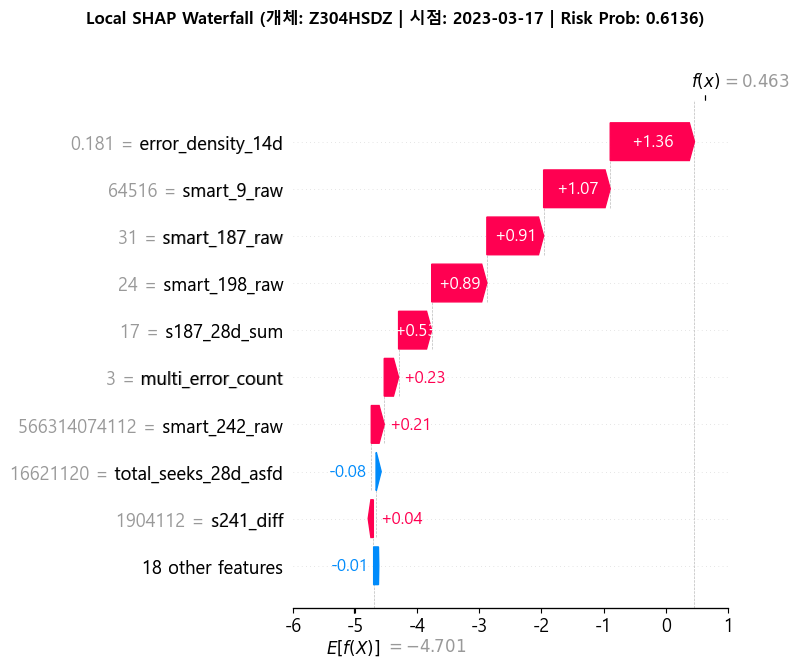

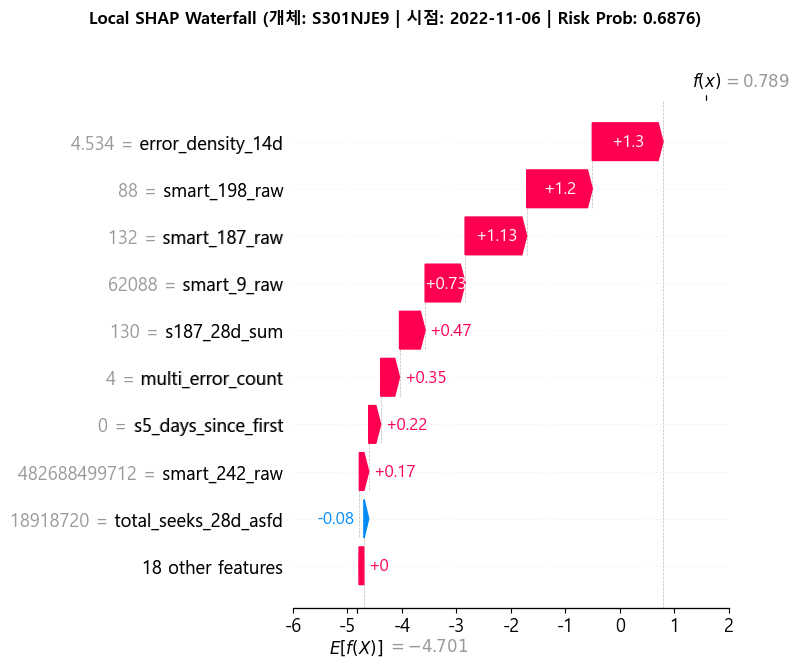

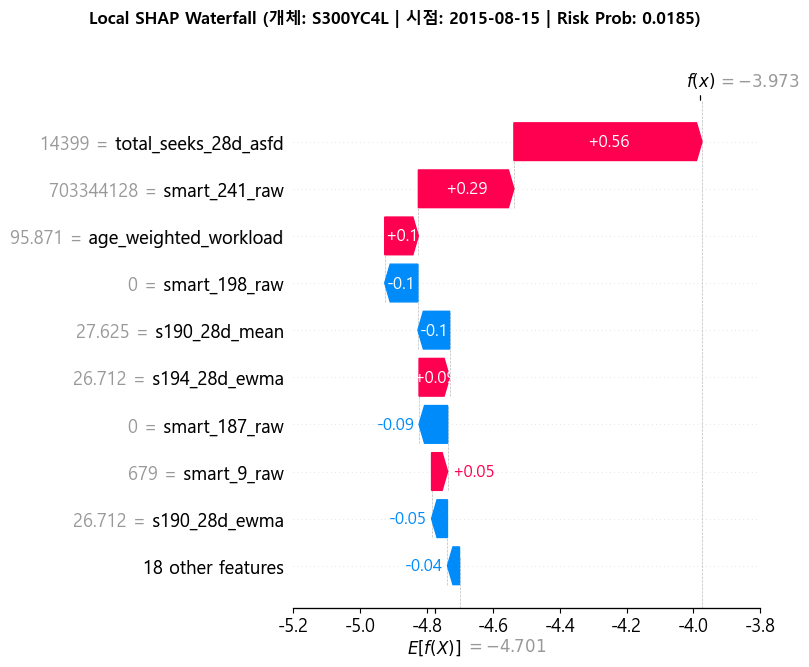

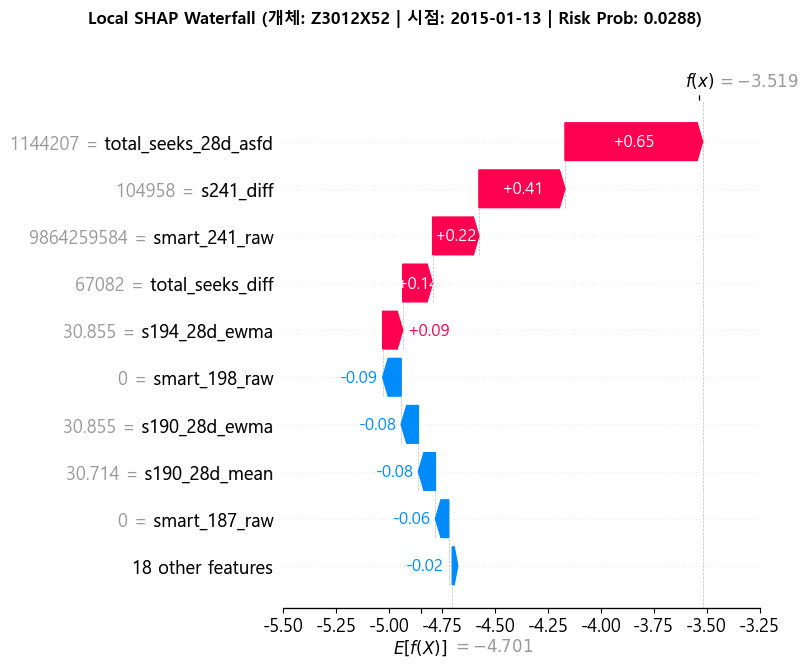

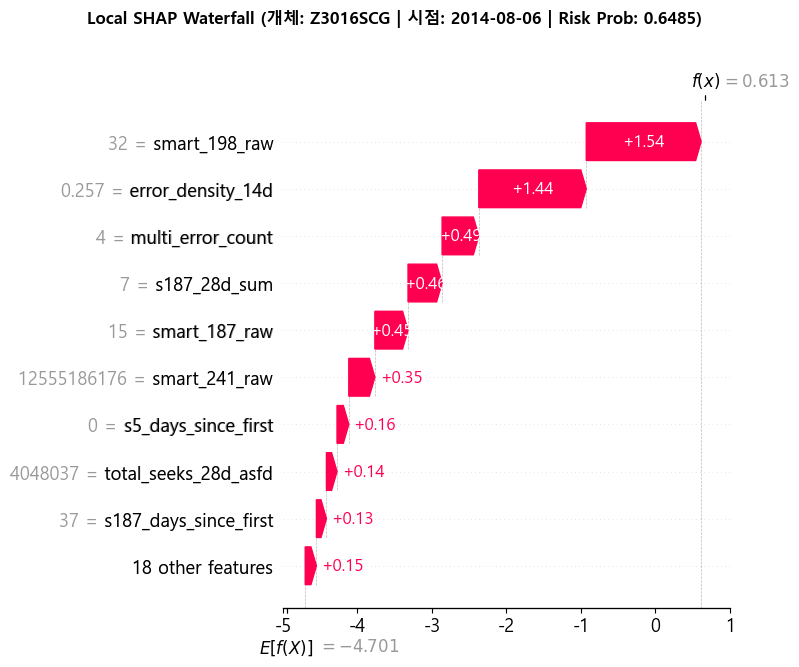

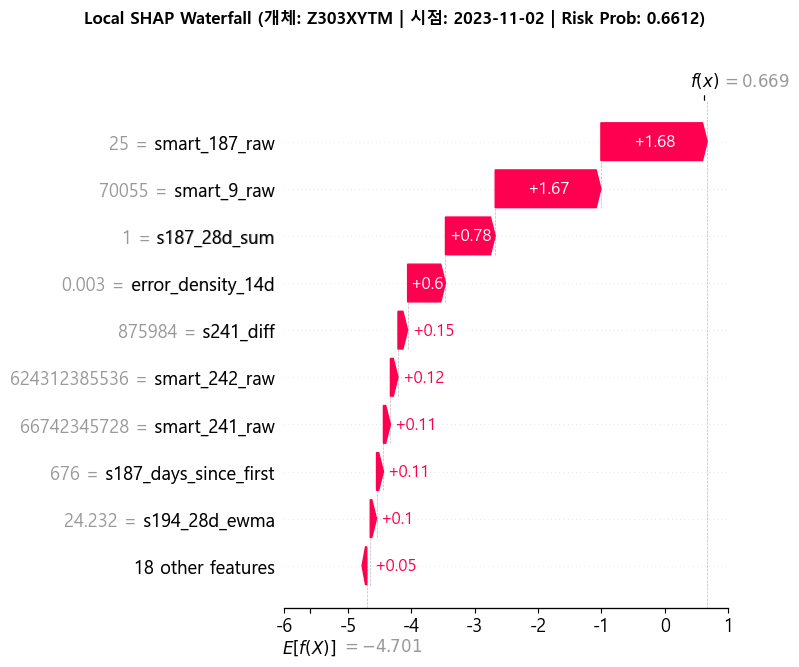

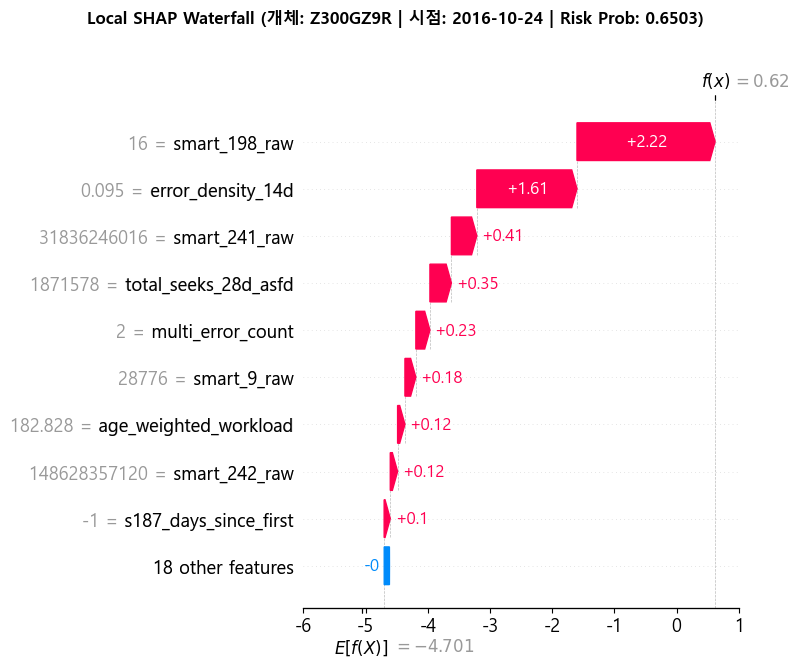

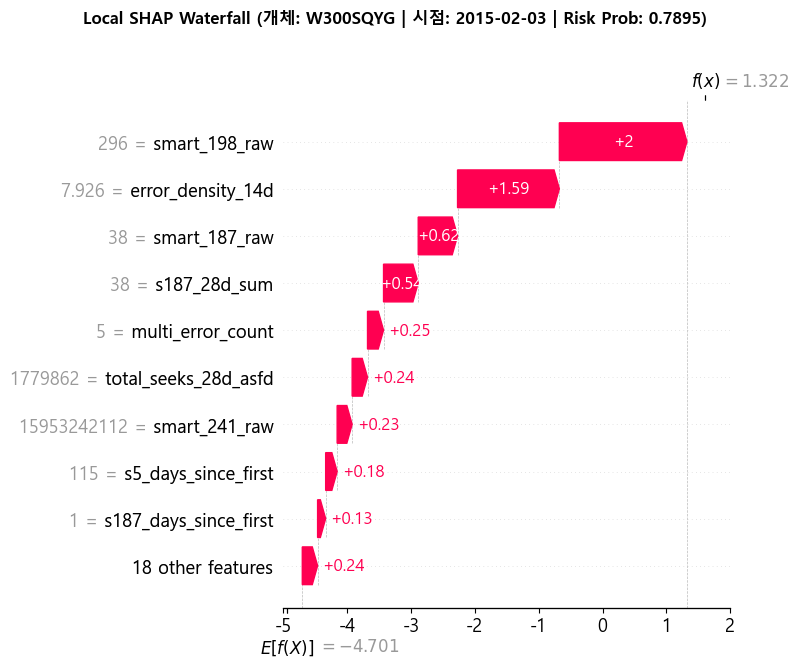

In [270]:
# 9. 국소적(Local) SHAP 분석 - 주요 시점 Waterfall Plot (인코딩 및 화살표 버그 해결)
print("Waterfall 플롯을 생성합니다...")

all_selected_serials = []
for cat, serials in cases.items():
    all_selected_serials.extend(serials)

for serial in all_selected_serials:
    df_entity = df_val[df_val['serial_number'].str.startswith(serial)].sort_values("date").reset_index(drop=True)
    if len(df_entity) == 0:
        continue

    probs = model.predict_proba(df_entity[FEATURE_COLS])[:, 1]
    max_idx = np.argmax(probs)
    row = df_entity.iloc[[max_idx]]
    X_row = row[FEATURE_COLS].copy()
    for col in X_row.columns:
        X_row[col] = X_row[col].astype("float32")

    exp_obj = shap.TreeExplainer(model)
    sv = exp_obj.shap_values(X_row)
    if isinstance(sv, list):
        sv = sv[1]
        ev = exp_obj.expected_value[1]
    else:
        ev = exp_obj.expected_value

    explanation = shap.Explanation(
        values=sv[0],
        base_values=ev,
        data=X_row.values[0],
        feature_names=FEATURE_COLS
    )

    date_val = row['date'].iloc[0]
    if isinstance(date_val, str):
        date_str = date_val.split('T')[0].split(' ')[0]
    else:
        date_str = pd.to_datetime(date_val).strftime('%Y-%m-%d')

    title = f"Local SHAP Waterfall (개체: {serial} | 시점: {date_str} | Risk Prob: {probs[max_idx]:.4f})"
    
    # shap 공식 waterfall plot 사용
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(explanation, max_display=10, show=False)
    
    # 마이너스 기호 깨짐 해결
    fig = plt.gcf()
    fig.canvas.draw()
    for ax in fig.axes:
        for t in ax.texts:
            t.set_text(t.get_text().replace('\u2212', '-'))
        ax.set_xticks(ax.get_xticks())
        labels = [l.get_text().replace('\u2212', '-') for l in ax.get_xticklabels()]
        ax.set_xticklabels(labels)
        ax.set_yticks(ax.get_yticks())
        labels = [l.get_text().replace('\u2212', '-') for l in ax.get_yticklabels()]
        ax.set_yticklabels(labels)
        
    fig.suptitle(title, fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()



📂 카테고리: 정탐 (True Positive) 시각화 진행 중...


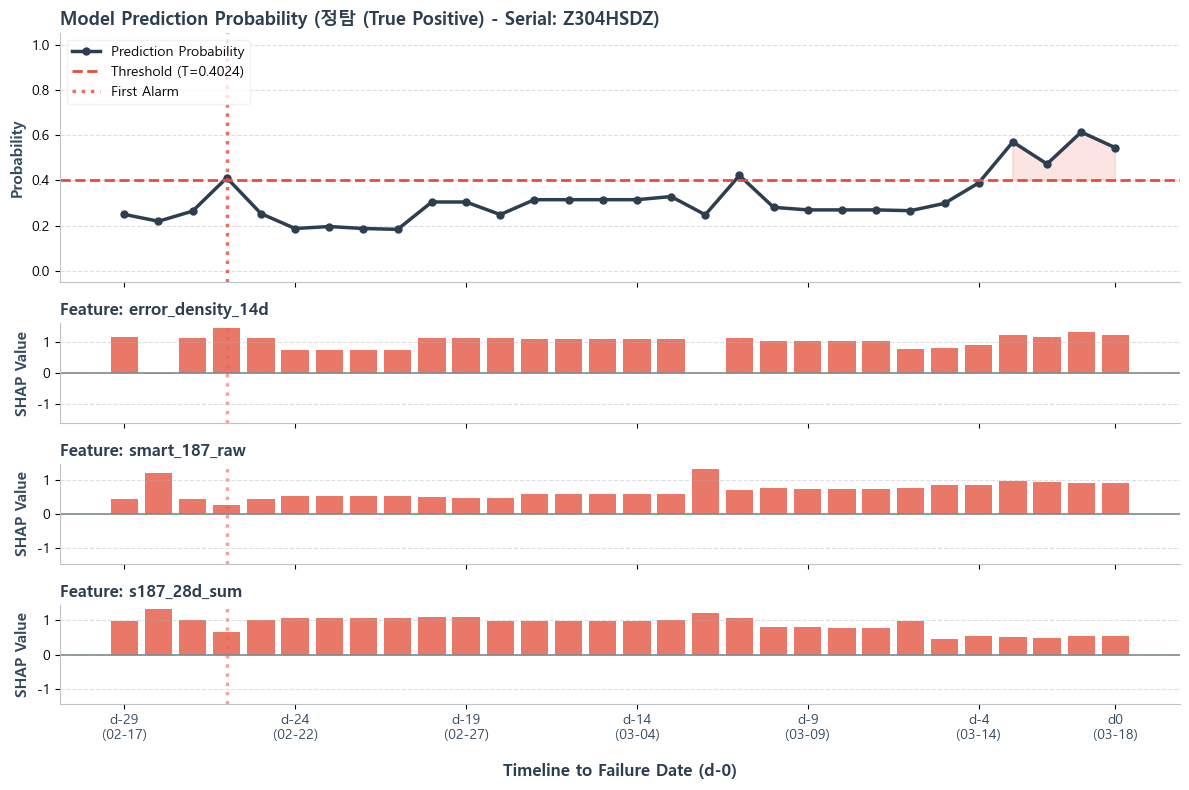

✅ 개체 Z304HSDZ 시각화 완료.


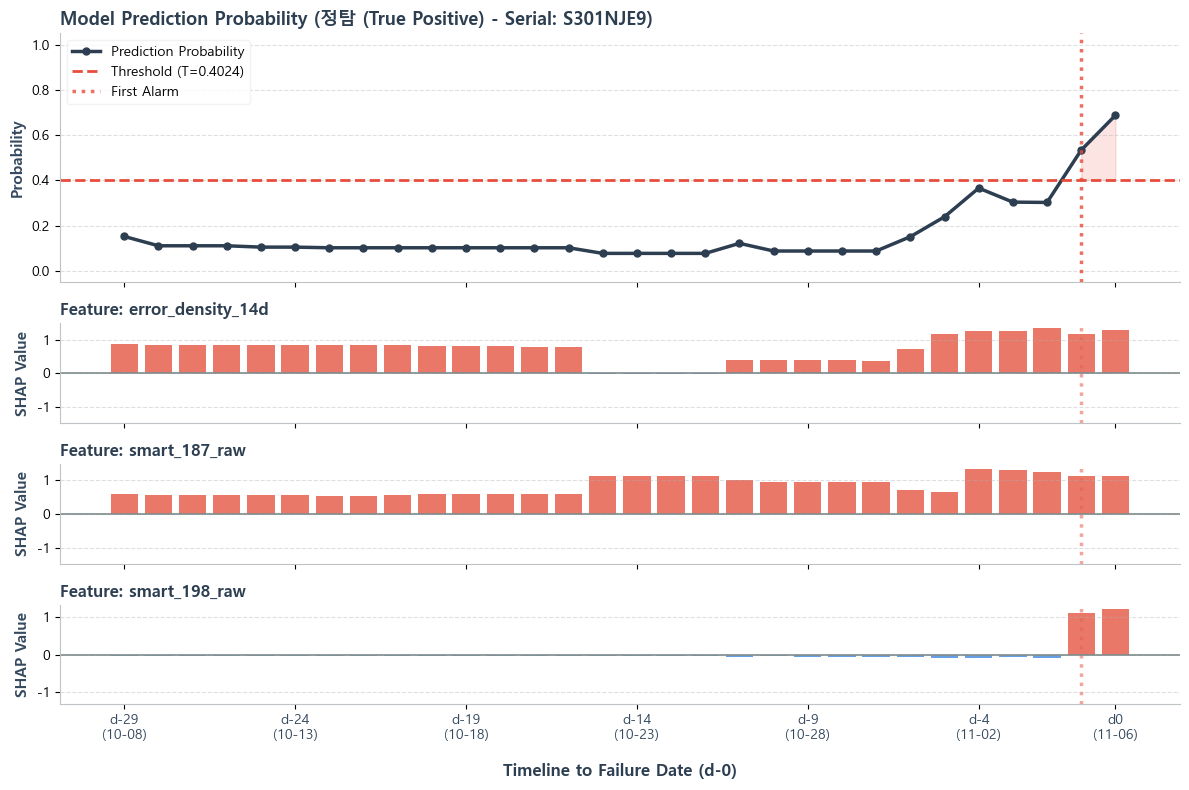

✅ 개체 S301NJE9 시각화 완료.

📂 카테고리: 미탐 (False Negative) 시각화 진행 중...


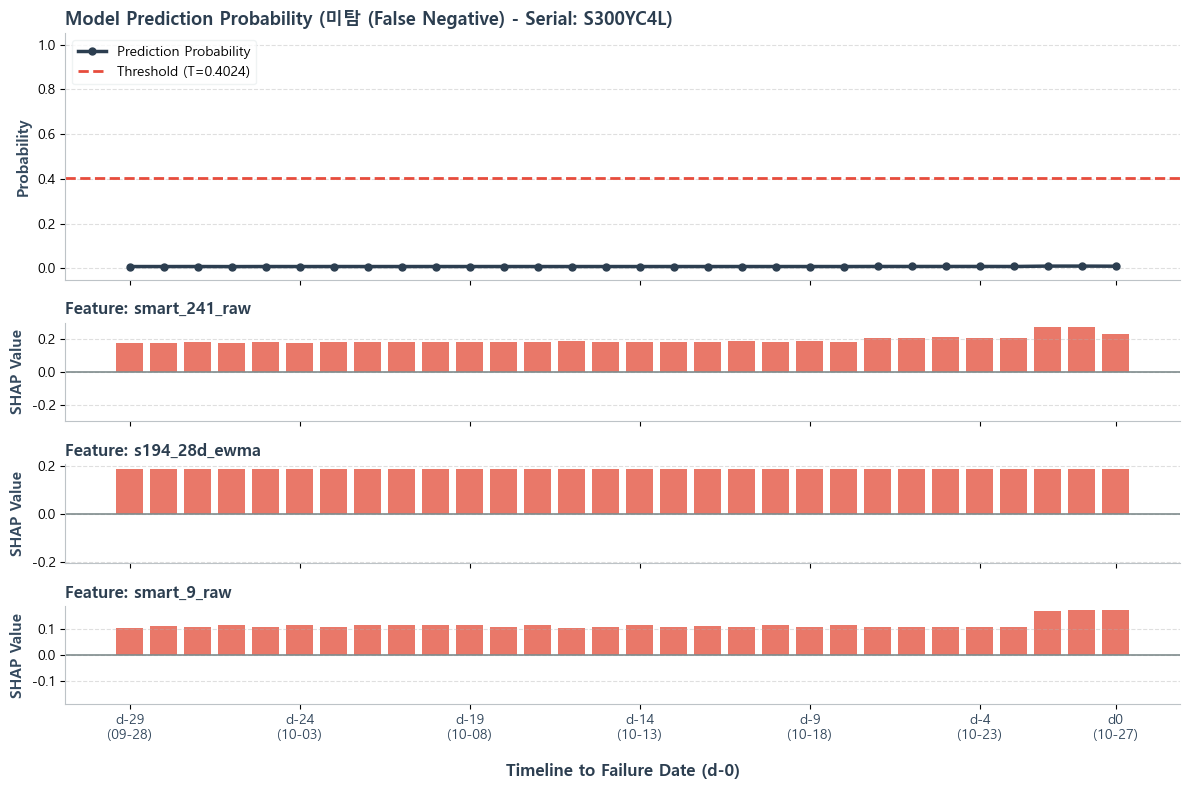

✅ 개체 S300YC4L 시각화 완료.


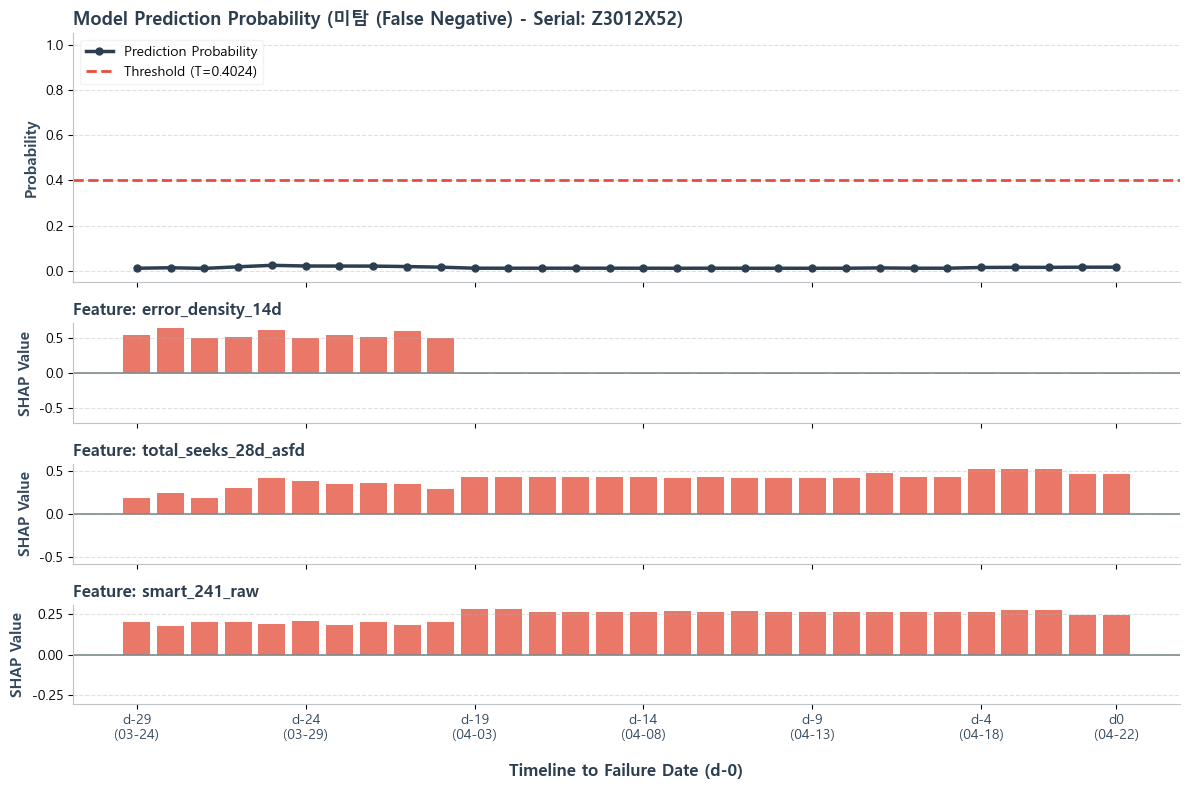

✅ 개체 Z3012X52 시각화 완료.

📂 카테고리: 정상에서의 오탐 (Normal False Alarm) 시각화 진행 중...


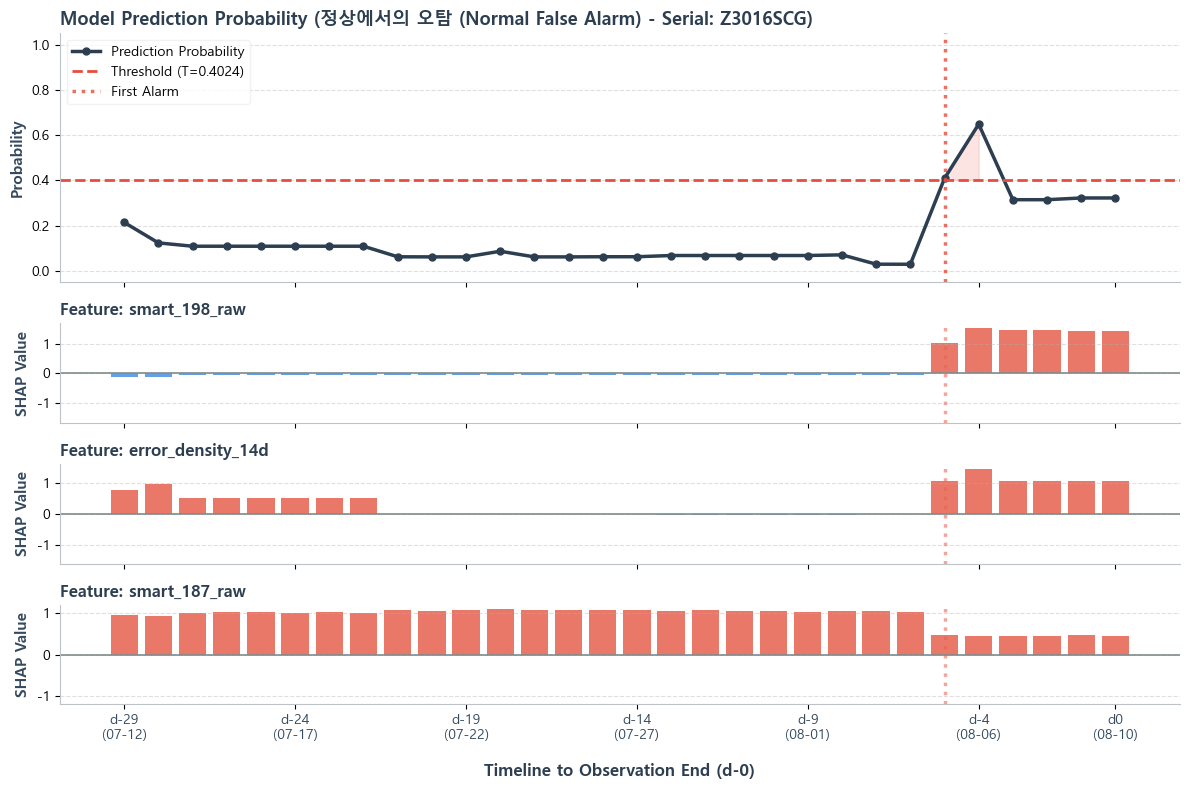

✅ 개체 Z3016SCG 시각화 완료.


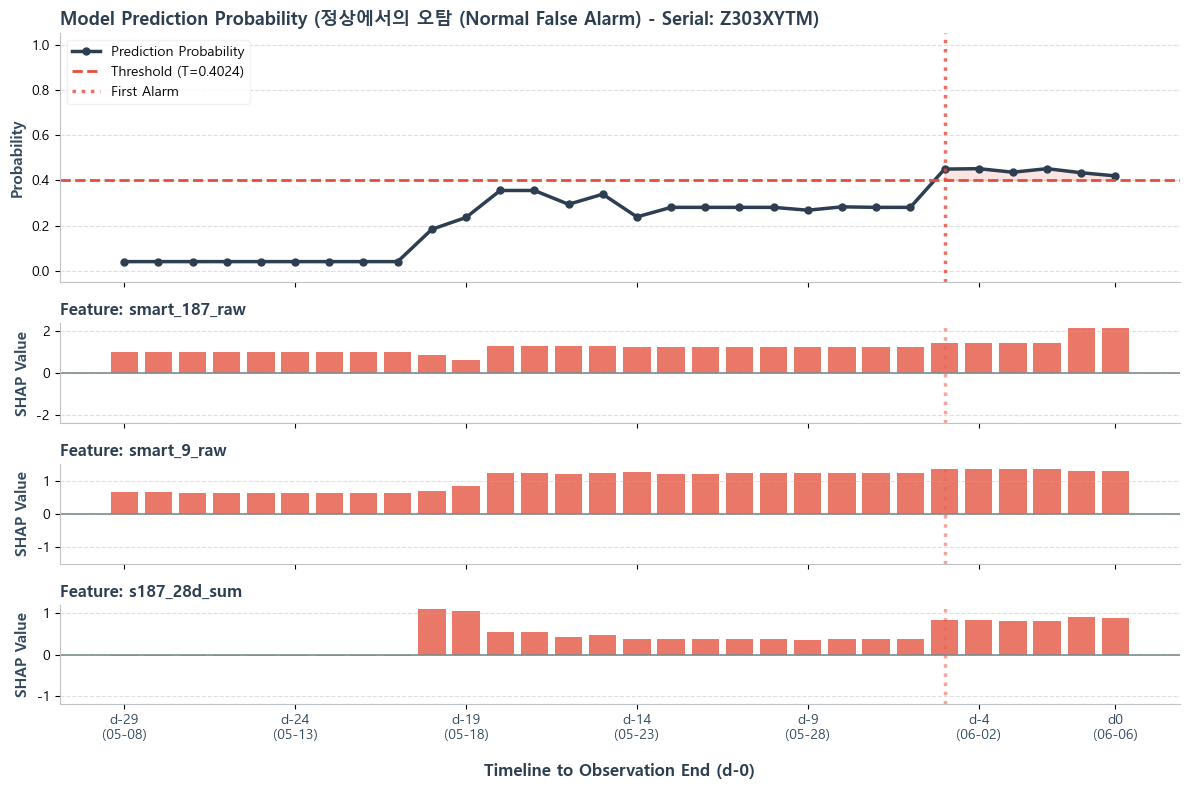

✅ 개체 Z303XYTM 시각화 완료.

📂 카테고리: 고장개체에서의 오탐 (Early Alarm) 시각화 진행 중...


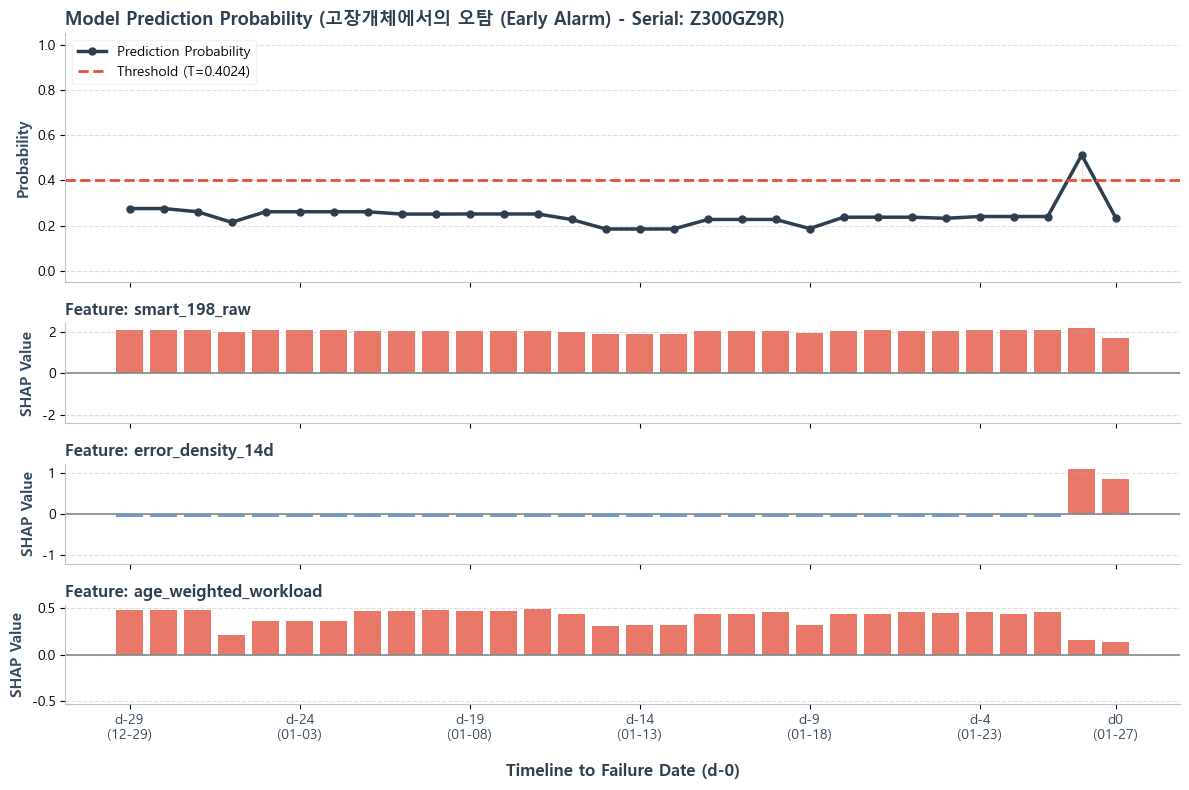

✅ 개체 Z300GZ9R 시각화 완료.


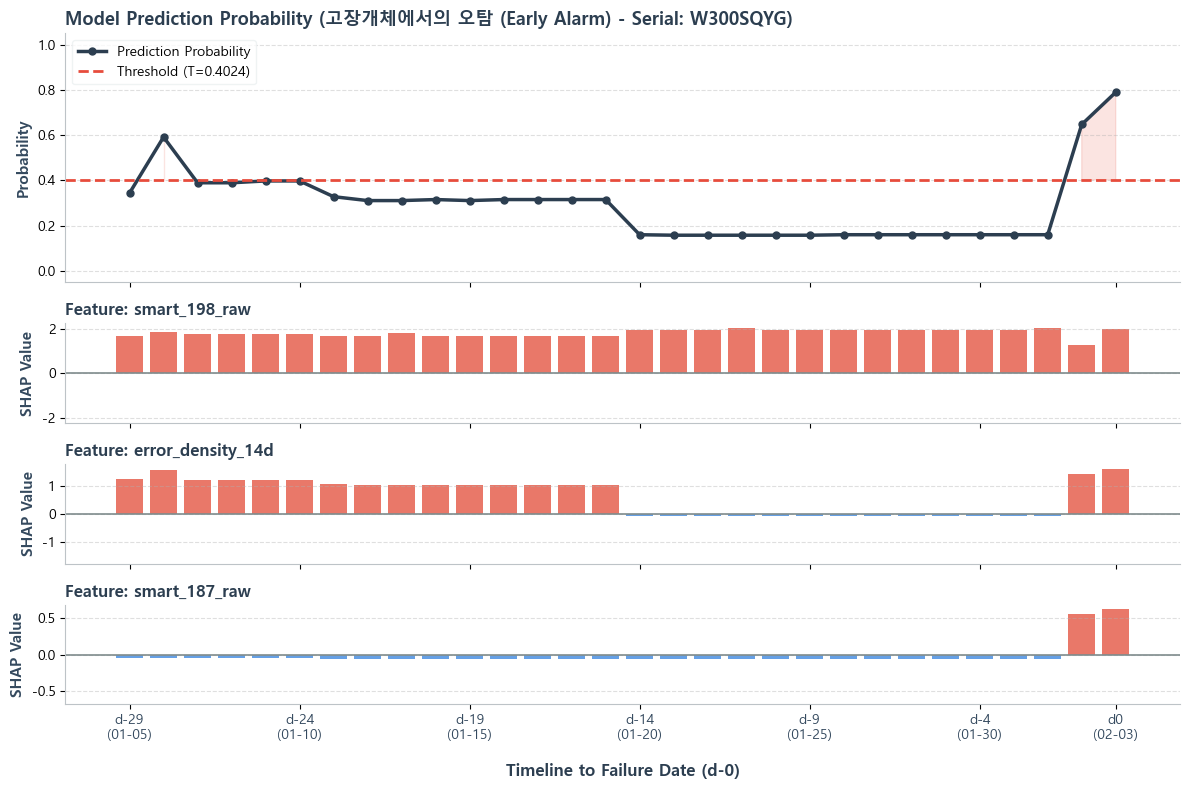

✅ 개체 W300SQYG 시각화 완료.


In [271]:
# 10. 국소적(Local) SHAP 분석 - 30일 시간 기반 SHAP Trajectory (Compact Layout)
window_days = 30
top_n = 3

for cat, serials in cases.items():
    print(f"\n{'='*80}\n📂 카테고리: {cat} 시각화 진행 중...\n{'='*80}")
    for serial in serials:
        df_entity = df_val[df_val['serial_number'].str.startswith(serial)].sort_values("date").reset_index(drop=True)
        df_entity = df_entity.copy()
        df_entity["_prob"] = model.predict_proba(df_entity[FEATURE_COLS])[:, 1]
        
        is_failed = int(df_entity['failure'].max() == 1)
        alarms = (df_entity['_prob'] >= BEST_T).astype(int)
        alarm_idx = np.where(alarms >= 1)[0]
        has_alarm = len(alarm_idx) > 0
        first_alarm_date = pd.Timestamp(df_entity['date'].iloc[alarm_idx[0]]) if has_alarm else None
        
        if is_failed == 1:
            ref_date = pd.Timestamp(df_entity['date'].max())
            title_suffix = "Failure Date (d-0)"
        else:
            if has_alarm and first_alarm_date is not None:
                ref_date = min(first_alarm_date + pd.Timedelta(days=5), pd.Timestamp(df_entity['date'].max()))
            else:
                ref_date = pd.Timestamp(df_entity['date'].max())
            title_suffix = "Observation End (d-0)"

        start_date = ref_date - pd.Timedelta(days=window_days - 1)
        
        df_entity['date_dt'] = pd.to_datetime(df_entity['date'])
        df_window = df_entity[(df_entity['date_dt'] >= start_date) & (df_entity['date_dt'] <= ref_date)].copy().reset_index(drop=True)
        
        if len(df_window) == 0:
            print(f"⚠️ {serial} 개체의 윈도우 데이터가 비어 있습니다. 건너뜁니다.")
            continue

        X_window = df_window[FEATURE_COLS].reset_index(drop=True)
        for col in X_window.columns:
            X_window[col] = X_window[col].astype("float32")

        exp = shap.TreeExplainer(model)
        sv_window = exp.shap_values(X_window)
        if isinstance(sv_window, list):
            sv_window = sv_window[1]

        max_pos_window = np.max(sv_window, axis=0) 
        top_feat_idx = np.argsort(max_pos_window)[::-1][:top_n]
        top_feat_names = [FEATURE_COLS[idx] for idx in top_feat_idx]
 
        dates = df_window['date_dt'].dt.date.values
        days_from_last = [- (ref_date.date() - d).days for d in dates]

        fig, axes = plt.subplots(top_n + 1, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [2.5] + [1]*top_n})
        fig.patch.set_facecolor('#ffffff')
        
        ax_prob = axes[0]
        probs = df_window["_prob"].values
        
        ax_prob.plot(days_from_last, probs, marker='o', color='#2c3e50', lw=2.5, markersize=5, label="Prediction Probability")
        ax_prob.axhline(BEST_T, color='#e74c3c', linestyle='--', lw=2, label=f"Threshold (T={BEST_T:.4f})")
        ax_prob.fill_between(days_from_last, probs, BEST_T, where=(probs >= BEST_T), color='#e74c3c', alpha=0.15)
        
        if first_alarm_date is not None:
            alarm_day = - (ref_date.date() - first_alarm_date.date()).days
            if -window_days <= alarm_day <= 0:
                ax_prob.axvline(alarm_day, color='#e74c3c', linestyle=':', lw=2.5, alpha=0.8, label="First Alarm")

        ax_prob.set_ylabel("Probability", fontsize=11, fontweight="bold", color='#34495e')
        ax_prob.set_title(f"Model Prediction Probability ({cat} - Serial: {serial})", fontsize=13, fontweight="bold", loc='left', color='#2c3e50')
        ax_prob.set_ylim(-0.05, 1.05)
        ax_prob.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='#ecf0f1')
        ax_prob.grid(axis='y', linestyle='--', alpha=0.4)
        ax_prob.spines['top'].set_visible(False)
        ax_prob.spines['right'].set_visible(False)
        ax_prob.spines['left'].set_color('#bdc3c7')
        ax_prob.spines['bottom'].set_color('#bdc3c7')

        pos_color = '#e6614f'
        neg_color = '#4a90e2'
        
        for ax, feat_name, feat_idx in zip(axes[1:], top_feat_names, top_feat_idx):
            shap_vals = sv_window[:, feat_idx]
            bars = ax.bar(days_from_last, shap_vals, 
                          color=[pos_color if v > 0 else neg_color for v in shap_vals], 
                          alpha=0.85, width=0.8)
            ax.axhline(0, color="#7f8c8d", lw=1.2, ls="-")
            
            if first_alarm_date is not None:
                alarm_day = - (ref_date.date() - first_alarm_date.date()).days
                if -window_days <= alarm_day <= 0:
                    ax.axvline(alarm_day, color='#e74c3c', linestyle=':', lw=2.5, alpha=0.5, zorder=0)

            max_abs = max(abs(shap_vals.min()), abs(shap_vals.max())) * 1.1
            if max_abs > 0:
                ax.set_ylim(-max_abs, max_abs)
                
            ax.set_ylabel("SHAP Value", fontsize=11, fontweight="bold", color='#34495e')
            ax.set_title(f"Feature: {feat_name}", fontsize=12, fontweight="bold", loc='left', color='#2c3e50')
            ax.grid(axis="y", linestyle='--', alpha=0.4)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_color('#bdc3c7')
            ax.spines['bottom'].set_color('#bdc3c7')

        tick_locs = np.arange(-window_days + 1, 1, 5)
        if 0 not in tick_locs:
            tick_locs = np.append(tick_locs, 0)
        
        xticklabels = []
        for x in tick_locs:
            if x in days_from_last:
                tidx = days_from_last.index(x)
                real_date = dates[tidx].strftime('%m-%d')
            else:
                real_date = (ref_date + pd.Timedelta(days=int(x))).strftime('%m-%d')
            # d-n 형식 (d0는 고장일, d-5는 5일 전)
            day_label = "d0" if int(x) == 0 else f"d{int(x)}"
            xticklabels.append(f"{day_label}\n({real_date})")

        axes[-1].set_xticks(tick_locs)
        axes[-1].set_xticklabels(xticklabels, fontsize=10, color='#34495e')
        axes[-1].set_xlabel(f"Timeline to {title_suffix}", fontsize=12, fontweight="bold", color='#2c3e50', labelpad=15)

        plt.tight_layout()
        plt.show()
        print(f"✅ 개체 {serial} 시각화 완료.")
